---
# DNN : `MNIST` (avec `Keras`)
---

## Packages

In [1]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import keras
from keras import callbacks, layers, models
from keras.datasets import mnist

2025-10-02 11:21:45.735754: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-02 11:21:45.820562: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-02 11:21:47.408385: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


---
## 1. Données
---

### 1.1. Importation

In [2]:
valid_portion  = 1/5

(X_train_valid, y_train_valid), (X_test, y_test) = mnist.load_data()

X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=valid_portion)

print('Dimensions de X_train :', X_train.shape)
print('Dimensions de X_valid :', X_valid.shape)
print('Dimensions de X_test  :', X_test.shape)

print('Dimensions de y_train :', y_train.shape)
print('Dimensions de y_valid :', y_valid.shape)
print('Dimensions de y_test  :', y_test.shape)

Dimensions de X_train : (48000, 28, 28)
Dimensions de X_valid : (12000, 28, 28)
Dimensions de X_test  : (10000, 28, 28)
Dimensions de y_train : (48000,)
Dimensions de y_valid : (12000,)
Dimensions de y_test  : (10000,)


### 1.2. Graphiques

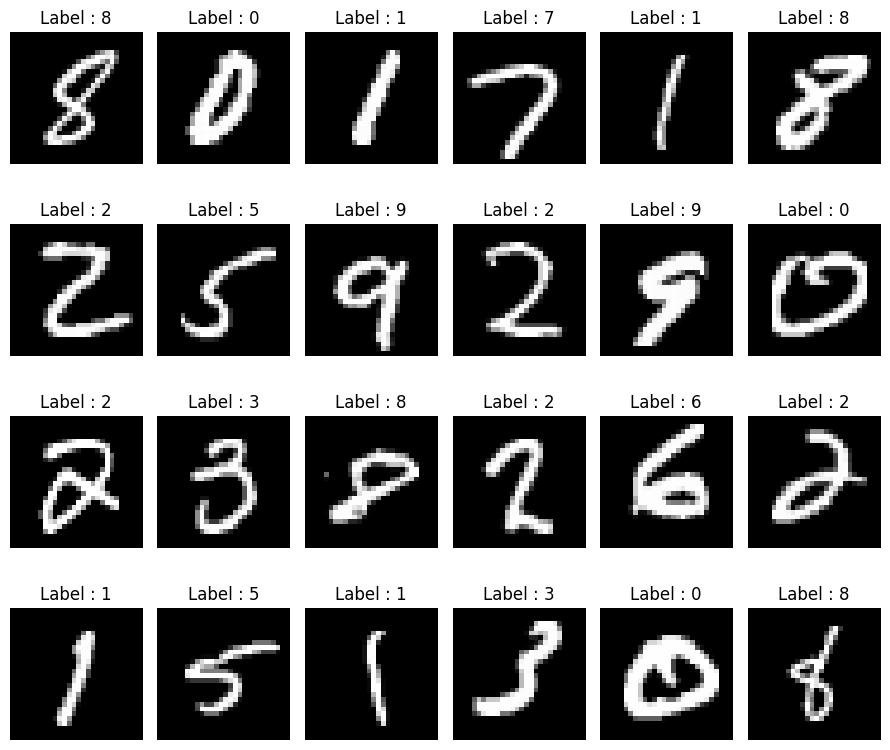

In [3]:
n_row = 4
n_col = 6
n = n_row * n_col

images = X_train[:n]
labels = y_train[:n]

fig, axes = plt.subplots(n_row, n_col, figsize=(1.5 * n_col, 2 * n_row))
for i in range(n):
    ax = axes[i//n_col, i%n_col]
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f'Label : {labels[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### 1.3. Normalisation

In [4]:
X_train_norm = X_train / 255
X_valid_norm = X_valid / 255
X_test_norm  = X_test  / 255

---
## 2. DNN
---

### 2.1. Architecture

In [12]:
dim_inputs  = (28, 28, 1)
dim_outputs = 10 #car classification non binaire avec 10 classes

n_units_hl1 = 100
n_units_hl2 = 100

dropout_hl1 = 0.2
dropout_hl2 = 0.2

model = models.Sequential(name='DNN')

model.add(layers.Input(shape=dim_inputs, name='Inputs'))

model.add(layers.Flatten(name='Flatten'))

# ...
model.add(layers.Dense(units=n_units_hl1, activation='relu', name='Hidden_layer_1'))

model.add(layers.Dense(units=n_units_hl2, activation='relu', name='Hidden_layer_2'))

model.add(layers.Dense(units=dim_outputs, activation='sigmoid', name='Output_layer'))

model.summary()

Model: "DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_layer_1 (Dense)          │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_layer_2 (Dense)          │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_layer (Dense)            │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,610 (350.04 KB)

 Trainable params: 89,610 (350.04 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2. Optimiseur

sparse_categorical_crossentropy

In [13]:
model.compile(optimizer = 'adam',
              loss      = 'sparse_categorical_crossentropy',
              metrics   = ['accuracy'])


callback = callbacks.EarlyStopping(monitor              = 'val_loss',
                                   mode                 = 'min',
                                   patience             = 20,
                                   restore_best_weights = True)

In [ ]:
hist = model.fit(X_train_norm,
                 y_train,
                 batch_size      = 500,
                 epochs          = 200,
                 validation_data = (X_valid_norm, y_valid),
                 callbacks       = [callback],
                 verbose         = 1)

Epoch 1/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8228 - loss: 0.6644 - val_accuracy: 0.9195 - val_loss: 0.2805
Epoch 2/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9302 - loss: 0.2420 - val_accuracy: 0.9392 - val_loss: 0.2118
Epoch 3/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9476 - loss: 0.1844 - val_accuracy: 0.9520 - val_loss: 0.1716
Epoch 4/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9581 - loss: 0.1460 - val_accuracy: 0.9591 - val_loss: 0.1469
Epoch 5/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9655 - loss: 0.1195 - val_accuracy: 0.9582 - val_loss: 0.1421
Epoch 6/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9709 - loss: 0.1009 - val_accuracy: 0.9640 - val_loss: 0.1266
Epoch 7/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9745 - loss: 0.0872 - val_accuracy: 0.9652 - val_loss: 0.1167
Epoch 8/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9773 - loss: 0.0761 - val_accuracy: 0.9658 - v

In [17]:
y_test_pred = model.predict(X_test_norm)
score_test = model.evaluate(X_test_norm, y_test, verbose=0)
score_test

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 640us/step


[0.08835449814796448, 0.9736999869346619]